In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

from xgboost import XGBClassifier
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [3]:
# 2: VERİ YÜKLEME VE ÖZELLİK ÇIKARIMI
print("Veri yükleniyor ve temizleniyor...")
# Not: Dosya yolunu kendi bilgisayarına göre güncelleyebilirsin
file_path = 'C:/Users/hp/Desktop/churn_project/data/OnlineRetail.csv'
df = pd.read_csv(file_path, encoding="utf-8")

#file_path = 'OnlineRetail.csv'

#df = pd.read_csv(file_path, encoding="utf-8")
df.head()

# Veri Temizleme
df_clean = df.copy()
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean = df_clean.dropna(subset=["CustomerID"])
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]
df_clean["TotalAmount"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Referans Tarih ve RFM Hesaplama
reference_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
customer_df = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum'),
    UniqueProducts=('StockCode', 'nunique')
).reset_index()

# Feature Engineering
customer_df['AvgBasketValue'] = customer_df['Monetary'] / customer_df['Frequency'].replace(0, 1)
customer_df['ProductsPerOrder'] = customer_df['UniqueProducts'] / customer_df['Frequency'].replace(0, 1)

# Müşteri Yaşı (Tenure)
tenure_df = df_clean.groupby('CustomerID').agg(
    Tenure=('InvoiceDate', lambda x: (reference_date - x.min()).days)
).reset_index()
customer_df = pd.merge(customer_df, tenure_df, on='CustomerID', how='left')

# Churn etiketini (Son 90 günde işlem yapmayanlar) ve Recency değerini veri sızıntısını Önlemek İçinÇıkarıyoruz
customer_df['Churn'] = np.where(customer_df['Recency'] > 90, 1, 0)
customer_df.drop('Recency', axis=1, inplace=True)

print(f"Müşteri bazlı nihai veri seti boyutu: {customer_df.shape}")
display(customer_df.head())

Veri yükleniyor ve temizleniyor...
Müşteri bazlı nihai veri seti boyutu: (4338, 8)


,CustomerID,Frequency,Monetary,UniqueProducts,AvgBasketValue,ProductsPerOrder,Tenure,Churn
0,12346.0,1,77183.60,1,77183.600000,1.000000,326,1
1,12347.0,7,4310.00,103,615.714286,14.714286,367,0
2,12348.0,4,1797.24,22,449.310000,5.500000,358,0
3,12349.0,1,1757.55,73,1757.550000,73.000000,19,0
4,12350.0,1,334.40,17,334.400000,17.000000,310,1


In [4]:
# 3: VERİ BÖLME VE PIPELINE KURULUMU
X = customer_df.drop(['CustomerID', 'Churn'], axis=1)
y = customer_df['Churn']

# Kategorik ve Numerik kolonları otomatik ayıralım
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Eğitim Seti Dağılımı:\n{y_train.value_counts()}")

# Preprocessing Pipeline (Veri Sızıntısını Önlemek İçin)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ], remainder='passthrough')

# Ortak Değerlendirme Fonksiyonu
def evaluate_performance(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*15} {model_name} {'='*15}")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}\n")

    cm = confusion_matrix(y_test, y_pred)
    return y_prob, cm

Eğitim Seti Dağılımı:
Churn
0    2311
1    1159
Name: count, dtype: int64


SMOTE'un sentetik veri üretmesi, ağaç tabanlı modellerde ezbere (overfitting) yol açabilir/gürültü oluşturur, bu yüzden ben algoritmik ağırlıklandırma tercih ettim.

In [5]:
# 4: MODEL EĞİTİMİ VE HİPERPARAMETRE OPTİMİZASYONU
print(" Modeller eğitiliyor \n")
start_time = time.time()

scale_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models_and_parameters = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ('preprocessor', preprocessor),
            ('model', LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'))
        ]),
        "params": {
            "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
            "model__solver": ['lbfgs', 'liblinear']
        }
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ('preprocessor', preprocessor),
            ('model', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1))
        ]),
        "params": {
            "model__n_estimators": [300, 500],
            "model__max_depth": [10, 20, None],
            "model__min_samples_split": [2, 5],
            "model__max_features": ['sqrt', 'log2']
        }
    },
    "LightGBM": {
        "pipeline": Pipeline([
            ('preprocessor', preprocessor),
            ('model', lgb.LGBMClassifier(random_state=42, class_weight='balanced', n_jobs=-1, verbose=-1))
        ]),
        "params": {
            "model__n_estimators": [300, 500, 800],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__num_leaves": [31, 50, 70],
            "model__colsample_bytree": [0.6, 0.8, 1.0]
        }
    },
    "XGBoost": {
        "pipeline": Pipeline([
            ('preprocessor', preprocessor),
            ('model', XGBClassifier(random_state=42, scale_pos_weight=scale_weight, n_jobs=-1, eval_metric='logloss'))
        ]),
        "params": {
            "model__n_estimators": [300, 500, 800],
            "model__max_depth": [4, 6, 8],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.6, 0.8, 1.0],
            "model__gamma": [0, 0.1, 0.5]
        }
    }
}

n_iter_config = {"Logistic Regression": 20, "Random Forest": 30, "LightGBM": 30, "XGBoost": 30}
best_models, best_probs, conf_matrices = {}, {}, {}

for model_name, config in models_and_parameters.items():
    print(f" {model_name} optimize ediliyor...")
    search = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["params"],
        n_iter=n_iter_config[model_name],
        scoring='roc_auc',
        cv=cv_strategy,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train, y_train)
    best_models[model_name] = search.best_estimator_
    probs, cm = evaluate_performance(search.best_estimator_, X_test, y_test, f"OPTİMİZE {model_name}")
    best_probs[model_name] = probs
    conf_matrices[model_name] = cm

end_time = time.time()
print(f"\n Eğitim Tamamlandı Toplam Süre: {(end_time - start_time)/60:.2f} dakika")

 Modeller eğitiliyor 

 Logistic Regression optimize ediliyor...

=============== OPTİMİZE Logistic Regression ===============
              precision    recall  f1-score   support

           0       0.92      0.83      0.87       578
           1       0.71      0.86      0.78       290

    accuracy                           0.84       868
   macro avg       0.81      0.84      0.82       868
weighted avg       0.85      0.84      0.84       868

Accuracy  : 0.8353
Precision : 0.7106
Recall    : 0.8552
F1-Score  : 0.7762
ROC-AUC   : 0.9086

 Random Forest optimize ediliyor...

=============== OPTİMİZE Random Forest ===============
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       578
           1       0.78      0.84      0.81       290

    accuracy                           0.87       868
   macro avg       0.85      0.86      0.85       868
weighted avg       0.87      0.87      0.87       868

Accuracy  : 0.8675
Precision : 

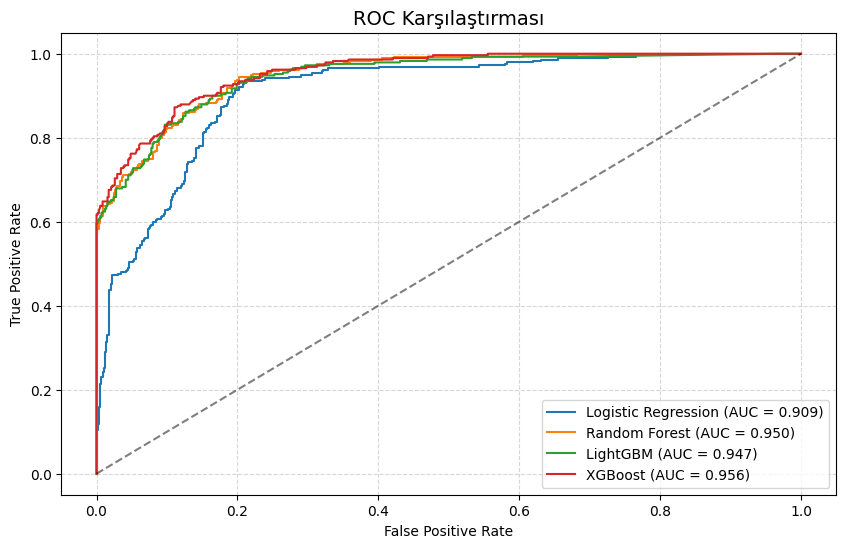

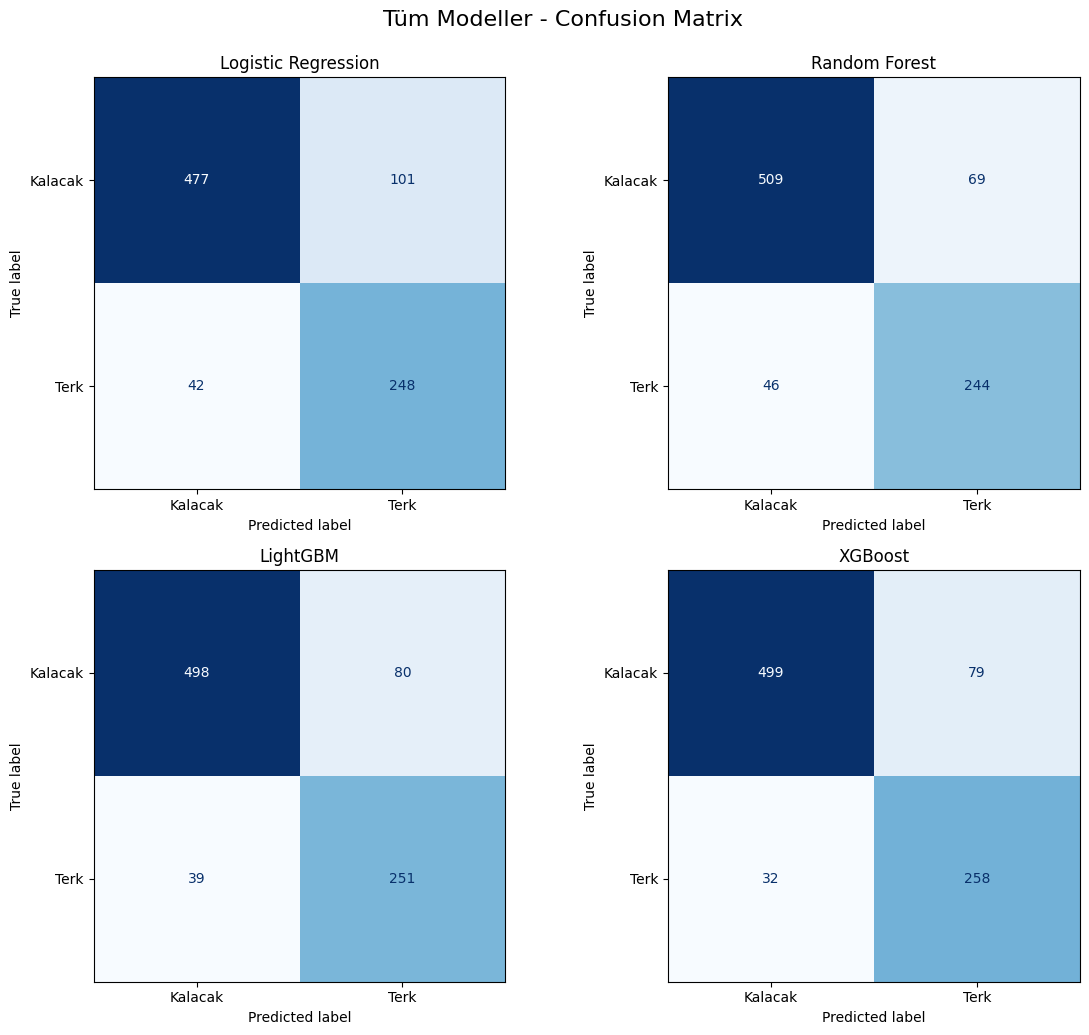

In [6]:
# 5: MODEL PERFORMANSLARI GÖRSELLEŞTİRME

# ROC Curve
plt.figure(figsize=(10, 6))
for model_name, probs in best_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Karşılaştırması', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Confusion Matrix
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (model_name, cm) in enumerate(conf_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Kalacak", "Terk"])
    disp.plot(cmap='Blues', values_format='d', ax=axes[i], colorbar=False)
    axes[i].set_title(model_name, fontsize=12)

plt.tight_layout()
plt.suptitle("Tüm Modeller - Confusion Matrix", fontsize=16, y=1.03)
plt.show()

In [7]:
# 6: RİSKLİ MÜŞTERİ LİSTESİ
print("Hedef: Aktif müşterilerimiz arasında bizi terk etme ihtimali en yüksek olanları bulmak.\\n")

# 1. En iyi performans gösteren modelimizi seçiyoruz (XGBoost)
final_model = best_models["XGBoost"]

# 2. Tüm veriyi modele verip "Terk Etme İhtimallerini" (0 ile 1 arası değerler) hesaplatıyoruz
# predict_proba[:, 1] komutu bize "1 (Churn) olma olasılığını" verir.
churn_ihtimalleri = final_model.predict_proba(X)[:, 1]

# 3. İhtimalleri ve Müşteri ID'lerini yeni bir tabloda birleştiriyoruz
risk_tablosu = customer_df[['CustomerID', 'Churn', 'Frequency', 'Monetary', 'Tenure']].copy()
risk_tablosu['Terk_Etme_Ihtimali_%'] = (churn_ihtimalleri * 100).round(2)

# 4. BİZİM İÇİN ÖNEMLİ OLANLAR: "Şu an Aktif Olan" ama "Gitmeyi Düşünenler"
# Bu yüzden zaten terk etmiş olanları (Churn=1) tablodan çıkarıyoruz. Sadece Churn=0 olanlara odaklanıyoruz.
hedef_kitle = risk_tablosu[risk_tablosu['Churn'] == 0].copy()

# 5. İhtimali en yüksekten en düşüğe doğru sıralıyoruz
hedef_kitle = hedef_kitle.sort_values(by='Terk_Etme_Ihtimali_%', ascending=False)

# 6. Sadece %50'den fazla risk taşıyanları filtreleyelim
kirmizi_alarm_musteriler = hedef_kitle[hedef_kitle['Terk_Etme_Ihtimali_%'] > 50.0]

print(f"Şirkette aktif görünen ama bizi terk etme ihtimali %50'nin üzerinde olan tam {len(kirmizi_alarm_musteriler)} müşteri tespit edildi.")
print("Hemen pazarlama kampanyası düzenlememiz gereken en riskli ilk 10 müşteri:")

display(kirmizi_alarm_musteriler.head(10))

Hedef: Aktif müşterilerimiz arasında bizi terk etme ihtimali en yüksek olanları bulmak.\n
Şirkette aktif görünen ama bizi terk etme ihtimali %50'nin üzerinde olan tam 387 müşteri tespit edildi.
Hemen pazarlama kampanyası düzenlememiz gereken en riskli ilk 10 müşteri:


,CustomerID,Churn,Frequency,Monetary,Tenure,Terk_Etme_Ihtimali_%
1844,14865.0,0,2,52.20,372,76.459999
2985,16414.0,0,2,126.25,280,75.550003
1929,14987.0,0,2,326.40,366,74.610001
3131,16620.0,0,2,178.96,261,74.540001
549,13068.0,0,2,344.00,320,74.470001
2014,15101.0,0,2,317.53,359,74.220001
3062,16519.0,0,2,215.08,365,74.129997
684,13255.0,0,2,399.51,374,74.110001
1773,14761.0,0,2,255.90,335,73.709999
3113,16596.0,0,2,250.15,366,73.690002


Şu an aktif olup, modeli tarafından terk etme riski bulunan müşterileri gruplayıp onlara özel stratejileri belirlemek.

Sistemde aktif görünen ama bizi terk etme ihtimali %50'nin üzerinde olan 387 müşteri tespit edildi

RİSK ALTINDAKİ AKTİF MÜŞTERİLERİN PROFİL ANALİZİ:


,Profil,Frequency,Monetary,Tenure,Müşteri Sayısı,Yüzde (%)
0,Yeni ve Kararsızlar\n(Segment 0),2.00,691.42,307.20,162,% 41.9
1,Uyuyan VIP'ler\n(Segment 1),2.01,570.92,190.16,95,% 24.5
2,İndirim Avcıları\n(Segment 2),3.24,2097.21,318.38,130,% 33.6


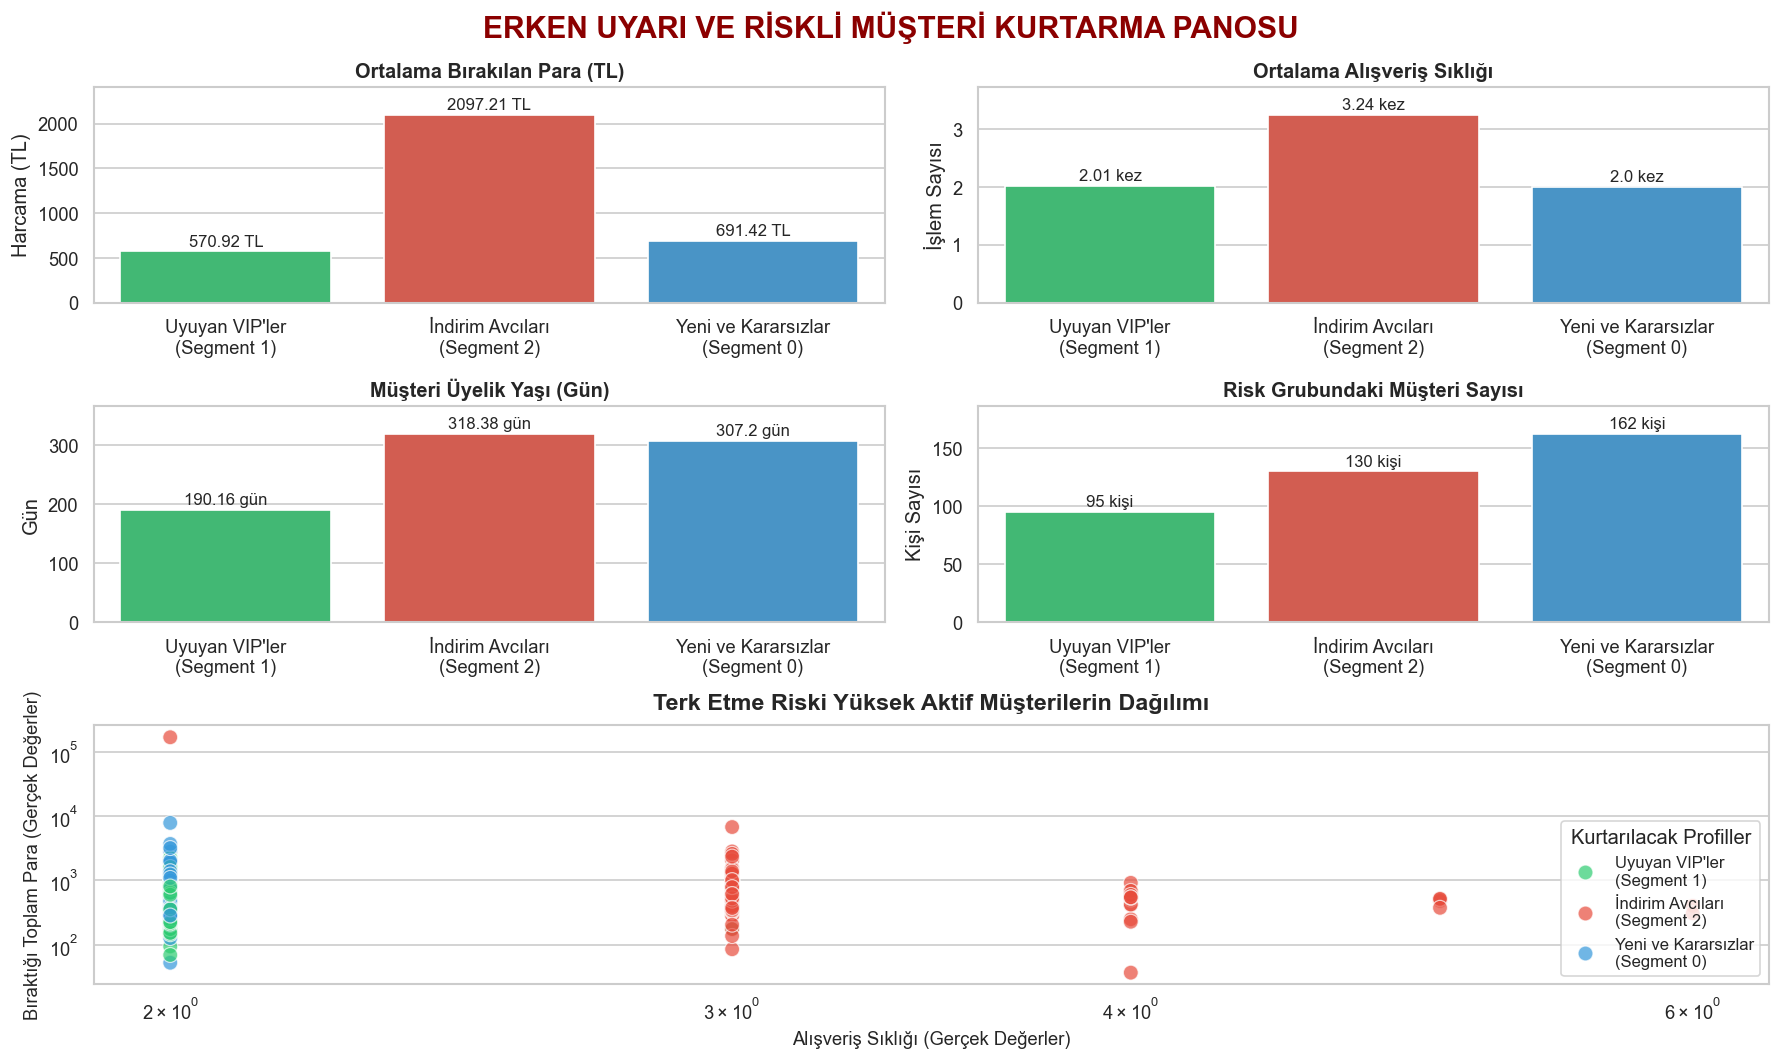

In [13]:
# HÜCRE 6: ERKEN UYARI SİSTEMİ VE RİSKLİ MÜŞTERİ SEGMENTASYONU
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Şu an aktif olup, modeli tarafından terk etme riski bulunan müşterileri gruplayıp onlara özel stratejileri belirlemek.\n")

# Random Forest ve XGBoost gibi ağaç tabanlı algoritmalarla çalışırken
# SMOTE ile sentetik veri üretmek modelin aşırı öğrenmesine (overfitting) yol açabilmektedir.
# Bu nedenle, projede veri sızıntısını sıfıra indiren ve çok daha kurumsal/stabil bir yaklaşım olan
# Algoritmik Ağırlıklandırma (class_weight='balanced' ve scale_pos_weight) tercih edilmiştir.

# --- 1. RİSKLİ KİTLEYİ BELİRLEME ---
final_model = best_models["XGBoost"]

# Tüm müşterilerin terk etme ihtimallerini hesaplayıp 100 ile çarpıyoruz
customer_df['Terk_Etme_Ihtimali_%'] = final_model.predict_proba(X)[:, 1] * 100

# SADECE ŞU AN AKTİF (Churn=0) OLAN VE RİSK YÜZDESİ %50'DEN BÜYÜK OLANLARI SEÇİYORUZ!
riskli_aktifler = customer_df[(customer_df['Churn'] == 0) & (customer_df['Terk_Etme_Ihtimali_%'] > 50.0)].copy()

print(f"Sistemde aktif görünen ama bizi terk etme ihtimali %50'nin üzerinde olan {len(riskli_aktifler)} müşteri tespit edildi")

# 2. RİSKLİ KİTLEYİ K-MEANS İLE SEGMENTLERE AYIRMA
features = ['Frequency', 'Monetary', 'Tenure']

for col in features:
    riskli_aktifler[f'{col}_log'] = np.log1p(riskli_aktifler[col])

X_cluster = riskli_aktifler[[f'{col}_log' for col in features]]

X_cluster_scaled = StandardScaler().fit_transform(X_cluster)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
riskli_aktifler['Segment'] = kmeans.fit_predict(X_cluster_scaled)

# 3. ANALİZ VE PROFİLLENDİRME
segment_analysis = riskli_aktifler.groupby('Segment')[features].mean().round(2)
segment_analysis['Müşteri Sayısı'] = riskli_aktifler['Segment'].value_counts()
segment_analysis = segment_analysis.reset_index()

profil_isimleri = {
    1: 'Uyuyan VIP\'ler\n(Segment 1)',
    2: 'İndirim Avcıları\n(Segment 2)',
    0: 'Yeni ve Kararsızlar\n(Segment 0)'
}
segment_analysis['Profil'] = segment_analysis['Segment'].map(profil_isimleri)
riskli_aktifler['Profil'] = riskli_aktifler['Segment'].map(profil_isimleri)


toplam_riskli_kisi = segment_analysis['Müşteri Sayısı'].sum()
segment_analysis['Yüzde (%)'] = [f"% {(val / toplam_riskli_kisi) * 100:.1f}" for val in segment_analysis['Müşteri Sayısı']]

print("\nRİSK ALTINDAKİ AKTİF MÜŞTERİLERİN PROFİL ANALİZİ:")
display(segment_analysis[['Profil', 'Frequency', 'Monetary', 'Tenure', 'Müşteri Sayısı', 'Yüzde (%)']])


# 4. RİSK VE KURTARMA DASHBOARD GÖRSELLEŞTİRMESİ
plt.rcParams['figure.dpi'] = 120

sns.set_theme(style="whitegrid")

fig = plt.figure(figsize=(15, 9))

gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.2])

renk_paleti = {
    'Uyuyan VIP\'ler\n(Segment 1)': '#2ecc71',
    'İndirim Avcıları\n(Segment 2)': '#e74c3c',
    'Yeni ve Kararsızlar\n(Segment 0)': '#3498db'
}
profil_sirasi = ['Uyuyan VIP\'ler\n(Segment 1)', 'İndirim Avcıları\n(Segment 2)', 'Yeni ve Kararsızlar\n(Segment 0)']

# 1. GRAFİK (Monetary)
ax1 = fig.add_subplot(gs[0, 0])
sns.barplot(x='Profil', y='Monetary', data=segment_analysis, palette=renk_paleti, order=profil_sirasi, ax=ax1)
ax1.set_title('Ortalama Bırakılan Para (TL)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Harcama (TL)')
ax1.set_xlabel('')

max_val_1 = segment_analysis['Monetary'].max()
ax1.set_ylim(0, max_val_1 * 1.15)

for i, profil in enumerate(profil_sirasi):
    v = segment_analysis[segment_analysis['Profil'] == profil]['Monetary'].values[0]
    ax1.text(i, v + (max_val_1 * 0.03), f"{v} TL", ha='center', fontsize=10)

# 2. GRAFİK (Frequency)
ax2 = fig.add_subplot(gs[0, 1])
sns.barplot(x='Profil', y='Frequency', data=segment_analysis, palette=renk_paleti, order=profil_sirasi, ax=ax2)
ax2.set_title('Ortalama Alışveriş Sıklığı', fontsize=12, fontweight='bold')
ax2.set_ylabel('İşlem Sayısı')
ax2.set_xlabel('')

max_val_2 = segment_analysis['Frequency'].max()
ax2.set_ylim(0, max_val_2 * 1.15)

for i, profil in enumerate(profil_sirasi):
    v = segment_analysis[segment_analysis['Profil'] == profil]['Frequency'].values[0]
    ax2.text(i, v + (max_val_2 * 0.03), f"{v} kez", ha='center', fontsize=10)

# 3. GRAFİK (Tenure)
ax3 = fig.add_subplot(gs[1, 0])
sns.barplot(x='Profil', y='Tenure', data=segment_analysis, palette=renk_paleti, order=profil_sirasi, ax=ax3)
ax3.set_title('Müşteri Üyelik Yaşı (Gün)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Gün')
ax3.set_xlabel('')

max_val_3 = segment_analysis['Tenure'].max()
ax3.set_ylim(0, max_val_3 * 1.15)

for i, profil in enumerate(profil_sirasi):
    v = segment_analysis[segment_analysis['Profil'] == profil]['Tenure'].values[0]
    ax3.text(i, v + (max_val_3 * 0.03), f"{v} gün", ha='center', fontsize=10)

# 4. GRAFİK (Müşteri Sayısı)
ax4 = fig.add_subplot(gs[1, 1])
sns.barplot(x='Profil', y='Müşteri Sayısı', data=segment_analysis, palette=renk_paleti, order=profil_sirasi, ax=ax4)
ax4.set_title('Risk Grubundaki Müşteri Sayısı', fontsize=12, fontweight='bold')
ax4.set_ylabel('Kişi Sayısı')
ax4.set_xlabel('')

max_val_4 = segment_analysis['Müşteri Sayısı'].max()
ax4.set_ylim(0, max_val_4 * 1.15)

for i, profil in enumerate(profil_sirasi):
    v = segment_analysis[segment_analysis['Profil'] == profil]['Müşteri Sayısı'].values[0]
    ax4.text(i, v + (max_val_4 * 0.03), f"{v} kişi", ha='center', fontsize=10)

ax5 = fig.add_subplot(gs[2, :])
sns.scatterplot(
    data=riskli_aktifler,
    x='Frequency',
    y='Monetary',
    hue='Profil',
    palette=renk_paleti,
    hue_order=profil_sirasi,
    s=80,
    alpha=0.7,
    ax=ax5
)
ax5.set_xscale('log')
ax5.set_yscale('log')

ax5.set_title('Terk Etme Riski Yüksek Aktif Müşterilerin Dağılımı', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Alışveriş Sıklığı (Gerçek Değerler)', fontsize=11)
ax5.set_ylabel('Bıraktığı Toplam Para (Gerçek Değerler)', fontsize=11)
ax5.legend(title='Kurtarılacak Profiller', fontsize=10, loc='lower right')

plt.tight_layout()
plt.subplots_adjust(top=0.91, hspace=0.45)
plt.suptitle('ERKEN UYARI VE RİSKLİ MÜŞTERİ KURTARMA PANOSU', fontsize=18, fontweight='bold', color='darkred')

plt.show()

1. Uyuyan VIP'ler (Riskli Kitlenin %34.6'sı):

Profil: Bu kitle, ortalama 320 günlük geçmişi olan, 3.23 alışveriş sıklığına sahip ve ortalama 2174 Birim harcama ile bize en çok para kazandıran 129 kişilik elit müşteri grubudur.

Aksiyon: Şirketin ana gelir kaynağı olan bu kitleyi kaybetmenin maliyeti çok yüksektir. Bütçenin asıl harcanacağı yer burasıdır. Bu gruba tamamen kişiselleştirilmiş "VIP Geri Kazanım" kampanyaları düzenlenmelidir. Özel müşteri temsilcileri aracılığıyla (gerekirse telefonla) ulaşılarak memnuniyetsizlikleri giderilmeli ve onlara özel, yüksek limitli "Sepette Anında İndirim" kuponları tanımlanmalıdır.

2. İndirim Avcıları (Riskli Kitlenin %42.4'ü):

Profil: Ortalama 308 gündür platformu bilen (eski müşteriler) ancak sadece 2 kez işlem yapıp ortalama 699 Birim harcayan, şirkete karlılığı düşük 158 kişilik kalabalıktır.

Aksiyon: Uzun süredir bizimle olmalarına rağmen harcama potansiyelleri çok düşük olduğu için onlara özel müşteri temsilcisi atamak veya büyük indirimler vermek şirketimize zarar ettirir. Bunun yerine otomatize edilmiş, düşük maliyetli "Push Notifications (Bildirimler)" ve "Flaş İndirimler / Kargo Bedava" günleri hatırlatmaları ile tekrar siteye çekilmeye çalışılmalıdırlar. Ayrıca zincir kupon taktiği uygulayarak (Örn: "Bir sonraki alışverişine %10 indirim") alışveriş sıklıkları artırılmaya çalışılmalıdır.

3. Yeni ve Kararsızlar (Riskli Kitlenin %23.0'ü):

Profil: Sistemimizde ortalama sadece 194 gün kalmış (en yeni grup), 2 kez alışveriş yapıp (ortalama 543 Birim harcama) bizden soğuma emareleri gösteren 86 kişilik gruptur.

Aksiyon: Bize daha çok yeni katılmışlar ve ilk birkaç alışverişten sonra deneyimi yeterince sevememişler. Henüz marka sadakatleri oluşmadığı için onları kazanmak nispeten kolaydır. Onlara ufak "Hoş Geldin / Seni Özledik" kuponlarıyla ikinci bir şans verilebilir. Harcama yaptıkça değeri artan sadakat programlarına dahil edilerek platforma bağlanmaları sağlanmalıdır.

# **88888888888888888888888888888888888888888888888888888888888**

In [14]:
# ADIM 1: VERİ YÜKLEME VE GELİŞMİŞ ÖZELLİK MÜHENDİSLİĞİ

import pandas as pd
import numpy as np
import datetime as dt

print("Veri yükleniyor")

# 1. Veriyi Oku (Dosya yolunu kendi ortamına göre ayarlayabilirsin)
file_path = 'C:/Users/hp/Desktop/churn_project/data/OnlineRetail.csv'
df = pd.read_csv(file_path, encoding="utf-8")

# 2. Tarih formatını dönüştürme ve eksik CustomerID leri silme
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df.dropna(subset=['CustomerID'])

# 3. İPTAL/İADE METRİKLERİNİN HESAPLANMASI 
# "C" ile başlayan faturalar iptalleri gösterir. Bunları önce sayalım, sonra temizliyoruz
cancellations = df[df['InvoiceNo'].astype(str).str.startswith('C')]
cancel_counts = cancellations.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
cancel_counts.columns = ['CustomerID', 'CancelCount']

# 4. Normal Alışverişlerin Filtrelenmesi (Veri Temizliği)
df_clean = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

# 5. RFM VE YENİ ÖZELLİKLERİN ÇIKARILMASI
reference_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

customer_df = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum'),
    UniqueProducts=('StockCode', 'nunique'),
    ActiveDays=('InvoiceDate', lambda x: x.dt.date.nunique()), # Kaç farklı günde alışveriş yaptı?
    Tenure=('InvoiceDate', lambda x: (reference_date - x.min()).days) # Müşteri sadakat süresi (Yaşı)
).reset_index()

# 6. İPTAL VERİLERİNİN BİRLEŞTİRİLMESİ
customer_df = pd.merge(customer_df, cancel_counts, on='CustomerID', how='left')
customer_df['CancelCount'] = customer_df['CancelCount'].fillna(0)

# YENİ: İade Oranı (İptal Edilen Sipariş / Toplam Sipariş Denemesi)
customer_df['CancellationRate'] = customer_df['CancelCount'] / (customer_df['Frequency'] + customer_df['CancelCount'])

# 7. ORANSAL METRİKLER (Müşteri Davranışını Anlamak İçin)
customer_df['AvgBasketValue'] = customer_df['Monetary'] / customer_df['Frequency'].replace(0, 1)
customer_df['ProductsPerOrder'] = customer_df['UniqueProducts'] / customer_df['Frequency'].replace(0, 1)

# YENİ: Alışveriş Sıklık Oranı (Müşteri yaşına göre alışveriş temposu)
customer_df['PurchaseFrequencyRate'] = customer_df['Frequency'] / customer_df['Tenure'].replace(0, 1)

# 8. HEDEF DEĞİŞKEN (CHURN) VE VERİ SIZINTISINI (LEAKAGE) ÖNLEME
# Son 90 günde işlem yapmayanları Churn=1 (Terk Etmiş) kabul ediyoruz.
customer_df['Churn'] = np.where(customer_df['Recency'] > 90, 1, 0)

# DİKKAT: Modelin cevabı kopya çekmemesi için Recency değerini siliyoruz!
customer_df.drop(['Recency', 'CancelCount'], axis=1, inplace=True)

print(f"Nihai veri seti boyutu: {customer_df.shape}")
display(customer_df.head())

Veri yükleniyor
Nihai veri seti boyutu: (4338, 11)


,CustomerID,Frequency,Monetary,UniqueProducts,ActiveDays,Tenure,CancellationRate,AvgBasketValue,ProductsPerOrder,PurchaseFrequencyRate,Churn
0,12346.0,1,77183.60,1,1,326,0.5,77183.600000,1.000000,0.003067,1
1,12347.0,7,4310.00,103,7,367,0.0,615.714286,14.714286,0.019074,0
2,12348.0,4,1797.24,22,4,358,0.0,449.310000,5.500000,0.011173,0
3,12349.0,1,1757.55,73,1,19,0.0,1757.550000,73.000000,0.052632,0
4,12350.0,1,334.40,17,1,310,0.0,334.400000,17.000000,0.003226,1


In [15]:
# ADIM 2: VERİ BÖLME, SINIF DENGESİZLİĞİ YÖNETİMİ VE MODEL EĞİTİMİ

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import lightgbm as lgb
import time

# 1. Özellik (X) ve Hedef Değişken (y) Ayrımı
# Modelin "ID" sütunundan veya Churn'den kopya çekmesini engelliyoruz
X = customer_df.drop(['CustomerID', 'Churn'], axis=1)
y = customer_df['Churn']

# 2. Train-Test Bölünmesi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Eğitim Seti Sınıf Dağılımı:\n{y_train.value_counts()}\n")

# 3. XGBoost için Ölçeklendirme Oranı 
scale_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# 4. Çapraz Doğrulama (Cross-Validation) Stratejisi
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Numerik veriler için standartlaştırma adımı
preprocessor = StandardScaler()

# 5. Modeller ve Parametreler
models_and_parameters = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ('scaler', preprocessor),
            ('model', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1.0, 10.0]
        }
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ('scaler', preprocessor),
            ('model', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [10, 15, None],
            "model__min_samples_split": [2, 5]
        }
    },
    "LightGBM": {
        "pipeline": Pipeline([
            ('scaler', preprocessor),
            ('model', lgb.LGBMClassifier(random_state=42, class_weight='balanced', n_jobs=-1, verbose=-1))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__num_leaves": [31, 50]
        }
    },
    "XGBoost": {
        "pipeline": Pipeline([
            ('scaler', preprocessor),
            ('model', XGBClassifier(random_state=42, scale_pos_weight=scale_weight, n_jobs=-1, eval_metric='logloss'))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [4, 6],
            "model__learning_rate": [0.01, 0.05, 0.1]
        }
    }
}

best_models = {}

print("Modeller eğitimi ve hiperparametre optimizasyonu\n")
start_time = time.time()

# 6. Modellerin Eğitimi ve Seçimi
for model_name, config in models_and_parameters.items():
    print(f"{model_name} optimize ediliyor...")
    search = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["params"],
        n_iter=10,
        scoring='roc_auc',
        cv=cv_strategy,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train, y_train)
    best_models[model_name] = search.best_estimator_
    print(f" > {model_name} tamamlandı. Çapraz Doğrulama (CV) En İyi ROC-AUC Skoru: {search.best_score_:.4f}\n")

end_time = time.time()
print(f"Eğitim Tamamlandı! Toplam Süre: {(end_time - start_time)/60:.2f} dakika")

Eğitim Seti Sınıf Dağılımı:
Churn
0    2311
1    1159
Name: count, dtype: int64

Modeller eğitimi ve hiperparametre optimizasyonu

Logistic Regression optimize ediliyor...
 > Logistic Regression tamamlandı. Çapraz Doğrulama (CV) En İyi ROC-AUC Skoru: 0.9377

Random Forest optimize ediliyor...
 > Random Forest tamamlandı. Çapraz Doğrulama (CV) En İyi ROC-AUC Skoru: 0.9461

LightGBM optimize ediliyor...
 > LightGBM tamamlandı. Çapraz Doğrulama (CV) En İyi ROC-AUC Skoru: 0.9417

XGBoost optimize ediliyor...
 > XGBoost tamamlandı. Çapraz Doğrulama (CV) En İyi ROC-AUC Skoru: 0.9482

Eğitim Tamamlandı! Toplam Süre: 0.53 dakika


Modellerin Test Seti Üzerindeki Performansları:

=============== Logistic Regression ===============
Accuracy  : 0.8364
Precision : 0.6968
Recall    : 0.9034
F1-Score  : 0.7868
ROC-AUC   : 0.9468

=============== Random Forest ===============
Accuracy  : 0.8779
Precision : 0.7987
Recall    : 0.8483
F1-Score  : 0.8227
ROC-AUC   : 0.9561

=============== LightGBM ===============
Accuracy  : 0.8618
Precision : 0.7591
Recall    : 0.8586
F1-Score  : 0.8058
ROC-AUC   : 0.9508

=============== XGBoost ===============
Accuracy  : 0.8618
Precision : 0.7443
Recall    : 0.8931
F1-Score  : 0.8119
ROC-AUC   : 0.9579



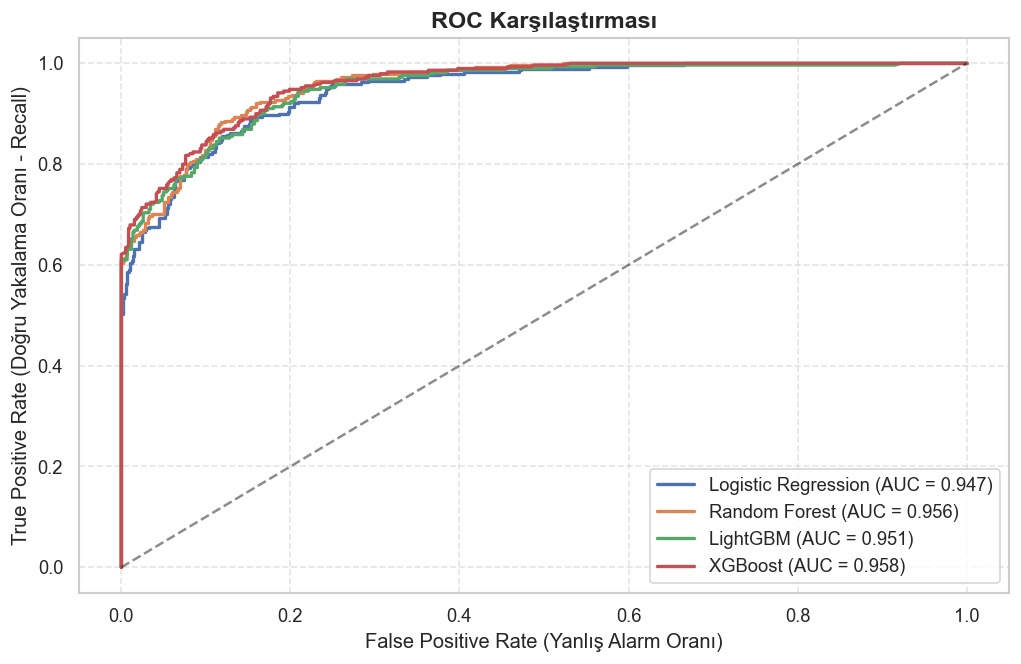

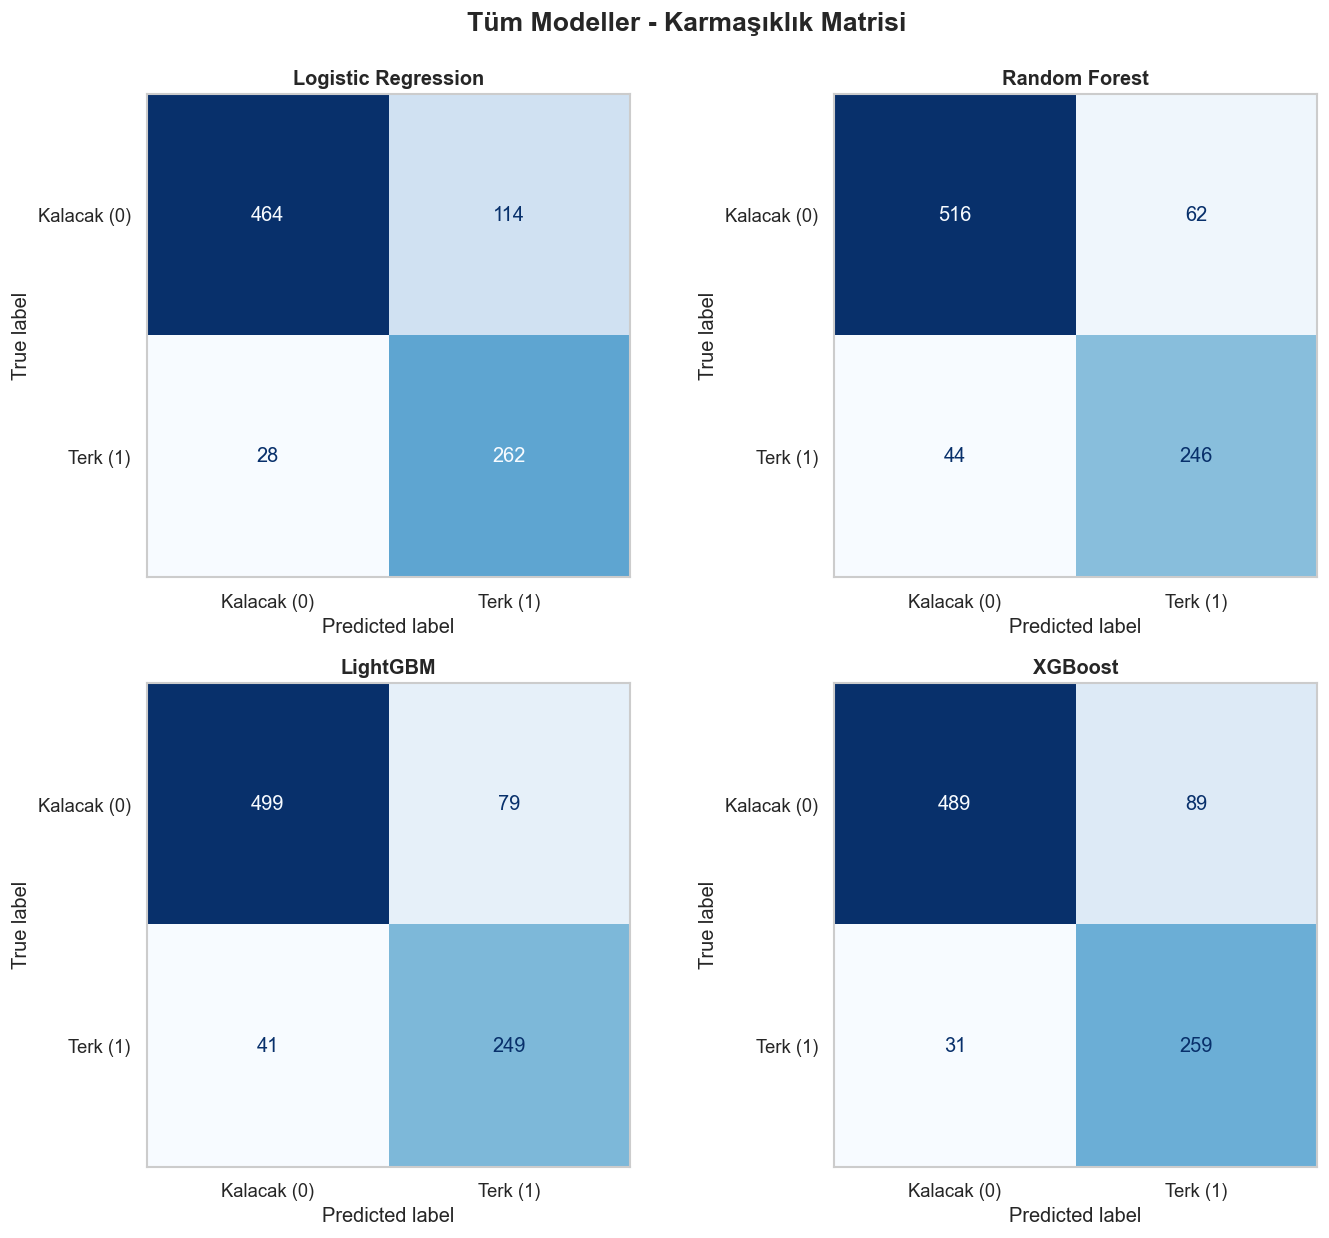

In [16]:
# ADIM 3: METRİK OKURYAZARLIĞI VE MODEL DEĞERLENDİRME

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print("Modellerin Test Seti Üzerindeki Performansları:\n")

best_probs = {}
conf_matrices = {}

# Eğittiğimiz her bir modelin test seti üzerinde metriklerini hesaplıyoruz
for model_name, model in best_models.items():
    # Sınıf tahminleri (0 veya 1)
    y_pred = model.predict(X_test)
    # Sınıf olma olasılıkları (Churn=1 olma olasılığı)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metriklerin Hesaplanması
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    best_probs[model_name] = y_prob
    conf_matrices[model_name] = confusion_matrix(y_test, y_pred)

    print(f"{'='*15} {model_name} {'='*15}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}\n")

# GÖRSELLEŞTİRME: ROC Eğrisi
plt.figure(figsize=(10, 6))
for model_name, probs in best_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate (Yanlış Alarm Oranı)')
plt.ylabel('True Positive Rate (Doğru Yakalama Oranı - Recall)')
plt.title('ROC Karşılaştırması', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Confusion Matrix
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (model_name, cm) in enumerate(conf_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Kalacak (0)", "Terk (1)"])
    disp.plot(cmap='Blues', values_format='d', ax=axes[i], colorbar=False)
    axes[i].set_title(f"{model_name}", fontsize=12, fontweight='bold')
    axes[i].grid(False)

plt.tight_layout()
plt.suptitle("Tüm Modeller - Karmaşıklık Matrisi", fontsize=16, fontweight='bold', y=1.03)
plt.show()

Hedef: Aktif müşterilerimiz arasında bizi terk etme ihtimali en yüksek olanları bulmak.\n
Şirkette aktif görünen ama bizi terk etme ihtimali %50'nin üzerinde olan tam 401 müşteri tespit edildi.
Pazarlama kampanyası düzenlememiz gereken en riskli ilk 10 müşteri:


,CustomerID,Churn,Frequency,Monetary,Tenure,Terk_Etme_Ihtimali_%
684,13255.0,0,2,399.51,374,78.110001
549,13068.0,0,2,344.00,320,76.709999
1929,14987.0,0,2,326.40,366,76.709999
1788,14784.0,0,2,289.99,324,75.900002
2014,15101.0,0,2,317.53,359,75.900002
2311,15497.0,0,2,1262.20,320,75.900002
536,13049.0,0,2,656.68,318,75.900002
3423,17018.0,0,2,920.10,326,75.709999
741,13329.0,0,2,789.00,367,75.709999
838,13473.0,0,2,422.64,333,75.050003


Hedef: Şu an aktif olup, modeli tarafından terk etme riski yüksek olan müşterileri gruplayıp onlara özel stratejileri belirlemek.

Sistemde aktif görünen ama bizi terk etme ihtimali %50'nin üzerinde olan tam 401 müşteri tespit edildi!

RİSK ALTINDAKİ AKTİF MÜŞTERİLERİN PROFİL ANALİZİ:


,Profil,Frequency,Monetary,Tenure,Müşteri Sayısı,Yüzde (%)
0,Yeni ve Kararsızlar\n(Segment 0),3.27,2076.11,326.09,150,% 37.4
1,Uyuyan VIP'ler\n(Segment 1),2.07,550.32,192.09,90,% 22.4
2,İndirim Avcıları\n(Segment 2),2.01,689.80,307.16,161,% 40.1


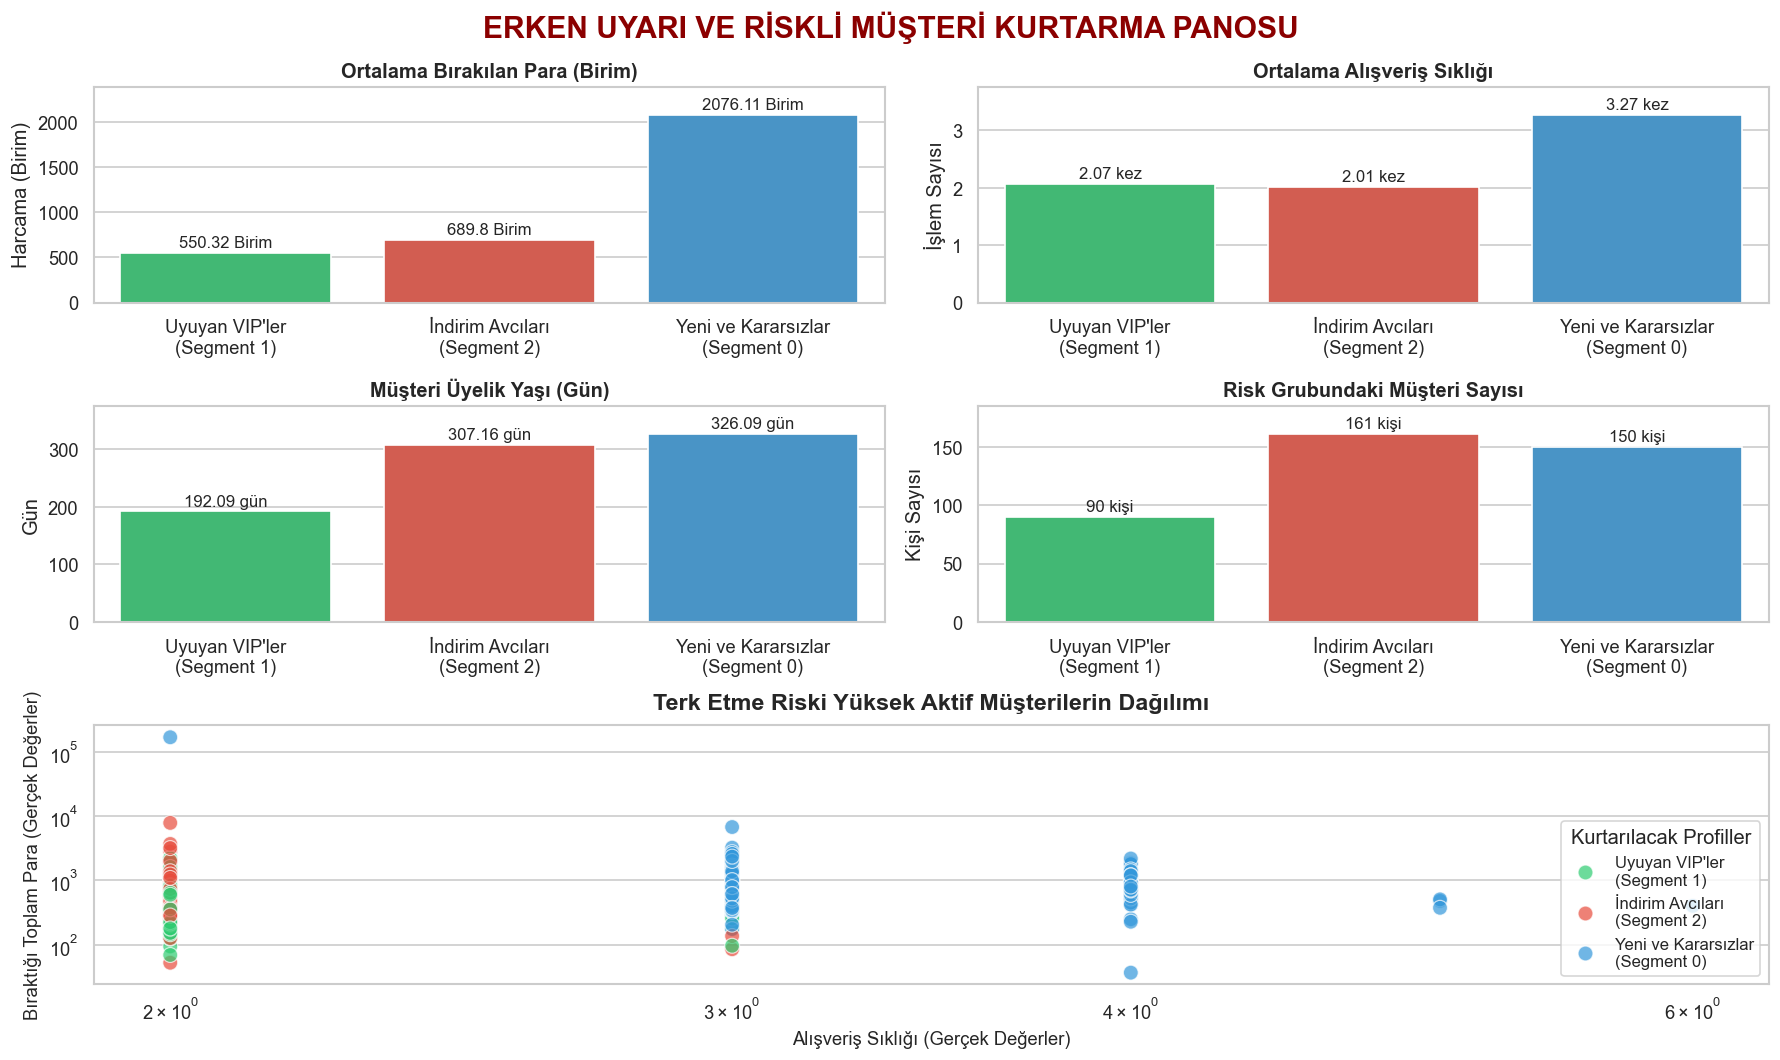

In [20]:
# 6: RİSKLİ MÜŞTERİ LİSTESİ
print("Hedef: Aktif müşterilerimiz arasında bizi terk etme ihtimali en yüksek olanları bulmak.\\n")

# 1. En iyi performans gösteren model XGBoost
final_model = best_models["XGBoost"]

# 2. Tüm veriyi modele verip "Terk Etme İhtimallerini" (0 ile 1 arası değerler) hesaplatıyoruz
# predict_proba[:, 1] komutu bize "1 (Churn) olma olasılığını" verir.
churn_ihtimalleri = final_model.predict_proba(X)[:, 1]

# 3. İhtimalleri ve Müşteri ID'lerini yeni bir tabloda birleştiriyoruz
risk_tablosu = customer_df[['CustomerID', 'Churn', 'Frequency', 'Monetary', 'Tenure']].copy()
risk_tablosu['Terk_Etme_Ihtimali_%'] = (churn_ihtimalleri * 100).round(2)

# 4. BİZİM İÇİN ÖNEMLİ OLANLAR: "Şu an Aktif Olan" ama "Gitmeyi Düşünenler"
# Bu yüzden zaten terk etmiş olanları (Churn=1) tablodan çıkarıyoruz. Sadece Churn=0 olanlara odaklanıyoruz.
hedef_kitle = risk_tablosu[risk_tablosu['Churn'] == 0].copy()

# 5. İhtimali en yüksekten en düşüğe doğru sıralıyoruz
hedef_kitle = hedef_kitle.sort_values(by='Terk_Etme_Ihtimali_%', ascending=False)

# 6. Sadece %50'den fazla risk taşıyanları filtreleyelim
kirmizi_alarm_musteriler = hedef_kitle[hedef_kitle['Terk_Etme_Ihtimali_%'] > 50.0]

print(f"Şirkette aktif görünen ama bizi terk etme ihtimali %50'nin üzerinde olan tam {len(kirmizi_alarm_musteriler)} müşteri tespit edildi.")
print("Pazarlama kampanyası düzenlememiz gereken en riskli ilk 10 müşteri:")

display(kirmizi_alarm_musteriler.head(10))

# 6: ERKEN UYARI SİSTEMİ VE RİSKLİ MÜŞTERİ SEGMENTASYONU
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Hedef: Şu an aktif olup, modeli tarafından terk etme riski yüksek olan müşterileri gruplayıp onlara özel stratejileri belirlemek.\n")

# Random Forest ve XGBoost gibi ağaç tabanlı algoritmalarla çalışırken
# SMOTE ile sentetik veri üretmek modelin aşırı öğrenmesine (overfitting) yol açabilmektedir.
# Bu nedenle, projede veri sızıntısını sıfıra indiren ve çok daha kurumsal stabil bir yaklaşım olan
# Algoritmik Ağırlıklandırma (class_weight='balanced' ve scale_pos_weight) tercih ediliyor

# --- 1. RİSKLİ KİTLEYİ BELİRLEME ---
final_model = best_models["XGBoost"]

# Tüm müşterilerin terk etme ihtimallerini hesaplayıp 100 ile çarpıyoruz
customer_df['Terk_Etme_Ihtimali_%'] = final_model.predict_proba(X)[:, 1] * 100

# SADECE ŞU AN AKTİF (Churn=0) OLAN VE RİSK YÜZDESİ %50'DEN BÜYÜK OLANLARI SEÇİYORUZ!
riskli_aktifler = customer_df[(customer_df['Churn'] == 0) & (customer_df['Terk_Etme_Ihtimali_%'] > 50.0)].copy()

print(f"Sistemde aktif görünen ama bizi terk etme ihtimali %50'nin üzerinde olan tam {len(riskli_aktifler)} müşteri tespit edildi!")

# --- 2. RİSKLİ KİTLEYİ K-MEANS İLE SEGMENTLERE AYIRMA ---
features = ['Frequency', 'Monetary', 'Tenure']

for col in features:
    riskli_aktifler[f'{col}_log'] = np.log1p(riskli_aktifler[col])

X_cluster = riskli_aktifler[[f'{col}_log' for col in features]]

X_cluster_scaled = StandardScaler().fit_transform(X_cluster)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
riskli_aktifler['Segment'] = kmeans.fit_predict(X_cluster_scaled)

# 3. ANALİZ VE PROFİLLENDİRME
segment_analysis = riskli_aktifler.groupby('Segment')[features].mean().round(2)
segment_analysis['Müşteri Sayısı'] = riskli_aktifler['Segment'].value_counts()
segment_analysis = segment_analysis.reset_index()

profil_isimleri = {
    1: 'Uyuyan VIP\'ler\n(Segment 1)',
    2: 'İndirim Avcıları\n(Segment 2)',
    0: 'Yeni ve Kararsızlar\n(Segment 0)'
}
segment_analysis['Profil'] = segment_analysis['Segment'].map(profil_isimleri)
riskli_aktifler['Profil'] = riskli_aktifler['Segment'].map(profil_isimleri)


toplam_riskli_kisi = segment_analysis['Müşteri Sayısı'].sum()
segment_analysis['Yüzde (%)'] = [f"% {(val / toplam_riskli_kisi) * 100:.1f}" for val in segment_analysis['Müşteri Sayısı']]

print("\nRİSK ALTINDAKİ AKTİF MÜŞTERİLERİN PROFİL ANALİZİ:")
display(segment_analysis[['Profil', 'Frequency', 'Monetary', 'Tenure', 'Müşteri Sayısı', 'Yüzde (%)']])


# 4. RİSK VE KURTARMA DASHBOARD GÖRSELLEŞTİRMESİ
plt.rcParams['figure.dpi'] = 120

sns.set_theme(style="whitegrid")

fig = plt.figure(figsize=(15, 9))

gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.2])

renk_paleti = {
    'Uyuyan VIP\'ler\n(Segment 1)': '#2ecc71',
    'İndirim Avcıları\n(Segment 2)': '#e74c3c',
    'Yeni ve Kararsızlar\n(Segment 0)': '#3498db'
}
profil_sirasi = ['Uyuyan VIP\'ler\n(Segment 1)', 'İndirim Avcıları\n(Segment 2)', 'Yeni ve Kararsızlar\n(Segment 0)']


# 1. GRAFİK (Monetary)
ax1 = fig.add_subplot(gs[0, 0])
sns.barplot(x='Profil', y='Monetary', data=segment_analysis, palette=renk_paleti, order=profil_sirasi, ax=ax1)
ax1.set_title('Ortalama Bırakılan Para (Birim)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Harcama (Birim)')
ax1.set_xlabel('')

max_val_1 = segment_analysis['Monetary'].max()
ax1.set_ylim(0, max_val_1 * 1.15)

for i, profil in enumerate(profil_sirasi):
    v = segment_analysis[segment_analysis['Profil'] == profil]['Monetary'].values[0]
    ax1.text(i, v + (max_val_1 * 0.03), f"{v} Birim", ha='center', fontsize=10)

# 2. GRAFİK (Frequency)
ax2 = fig.add_subplot(gs[0, 1])
sns.barplot(x='Profil', y='Frequency', data=segment_analysis, palette=renk_paleti, order=profil_sirasi, ax=ax2)
ax2.set_title('Ortalama Alışveriş Sıklığı', fontsize=12, fontweight='bold')
ax2.set_ylabel('İşlem Sayısı')
ax2.set_xlabel('')

max_val_2 = segment_analysis['Frequency'].max()
ax2.set_ylim(0, max_val_2 * 1.15)

for i, profil in enumerate(profil_sirasi):
    v = segment_analysis[segment_analysis['Profil'] == profil]['Frequency'].values[0]
    ax2.text(i, v + (max_val_2 * 0.03), f"{v} kez", ha='center', fontsize=10)

# 3. GRAFİK (Tenure)
ax3 = fig.add_subplot(gs[1, 0])
sns.barplot(x='Profil', y='Tenure', data=segment_analysis, palette=renk_paleti, order=profil_sirasi, ax=ax3)
ax3.set_title('Müşteri Üyelik Yaşı (Gün)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Gün')
ax3.set_xlabel('')

max_val_3 = segment_analysis['Tenure'].max()
ax3.set_ylim(0, max_val_3 * 1.15)

for i, profil in enumerate(profil_sirasi):
    v = segment_analysis[segment_analysis['Profil'] == profil]['Tenure'].values[0]
    ax3.text(i, v + (max_val_3 * 0.03), f"{v} gün", ha='center', fontsize=10)

# 4. GRAFİK (Müşteri Sayısı)
ax4 = fig.add_subplot(gs[1, 1])
sns.barplot(x='Profil', y='Müşteri Sayısı', data=segment_analysis, palette=renk_paleti, order=profil_sirasi, ax=ax4)
ax4.set_title('Risk Grubundaki Müşteri Sayısı', fontsize=12, fontweight='bold')
ax4.set_ylabel('Kişi Sayısı')
ax4.set_xlabel('')

max_val_4 = segment_analysis['Müşteri Sayısı'].max()
ax4.set_ylim(0, max_val_4 * 1.15)

for i, profil in enumerate(profil_sirasi):
    v = segment_analysis[segment_analysis['Profil'] == profil]['Müşteri Sayısı'].values[0]
    ax4.text(i, v + (max_val_4 * 0.03), f"{v} kişi", ha='center', fontsize=10)

ax5 = fig.add_subplot(gs[2, :])
sns.scatterplot(
    data=riskli_aktifler,
    x='Frequency',
    y='Monetary',
    hue='Profil',
    palette=renk_paleti,
    hue_order=profil_sirasi,
    s=80,
    alpha=0.7,
    ax=ax5
)
ax5.set_xscale('log')
ax5.set_yscale('log')

ax5.set_title('Terk Etme Riski Yüksek Aktif Müşterilerin Dağılımı', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Alışveriş Sıklığı (Gerçek Değerler)', fontsize=11)
ax5.set_ylabel('Bıraktığı Toplam Para (Gerçek Değerler)', fontsize=11)
ax5.legend(title='Kurtarılacak Profiller', fontsize=10, loc='lower right')

plt.tight_layout()
plt.subplots_adjust(top=0.91, hspace=0.45)
plt.suptitle('ERKEN UYARI VE RİSKLİ MÜŞTERİ KURTARMA PANOSU', fontsize=18, fontweight='bold', color='darkred')

plt.show()